# Random Forest Classifier - Analisis Dataset IRIS
## Perbandingan KNIME: Random Forest vs Decision Tree
---


## 1. Konsep Dasar Random Forest

**Random Forest** adalah algoritma *ensemble learning* yang membangun banyak Decision Tree secara paralel dan menggabungkan hasilnya.

| Komponen | Penjelasan |
|----------|------------|
| **Ensemble** | Menggabungkan banyak model untuk meningkatkan akurasi |
| **Bagging** | Bootstrap Aggregating - setiap tree dilatih dengan subset data acak |
| **Random Feature Selection** | Setiap split hanya mempertimbangkan subset fitur acak |
| **Voting** | Hasil akhir ditentukan oleh mayoritas vote dari semua tree |

### Keunggulan vs Decision Tree:
1. Lebih tahan terhadap **overfitting**
2. Lebih **akurat** - ensemble mengurangi variance
3. **Robust** terhadap noise dan outlier
4. Dapat menangani dataset besar dengan banyak fitur


## 2. Import Library & Load Data

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
warnings.filterwarnings('ignore')
try: plt.style.use('seaborn-v0_8-whitegrid')
except:
    try: plt.style.use('seaborn-whitegrid')
    except: pass
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Library berhasil di-import!')


Library berhasil di-import!


In [28]:
df = pd.read_csv('data/IRIS.csv')
print(f'Dataset: {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'\nDistribusi kelas:\n{df["species"].value_counts()}')
df.head()


Dataset: 150 baris x 5 kolom

Distribusi kelas:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Visualisasi Data

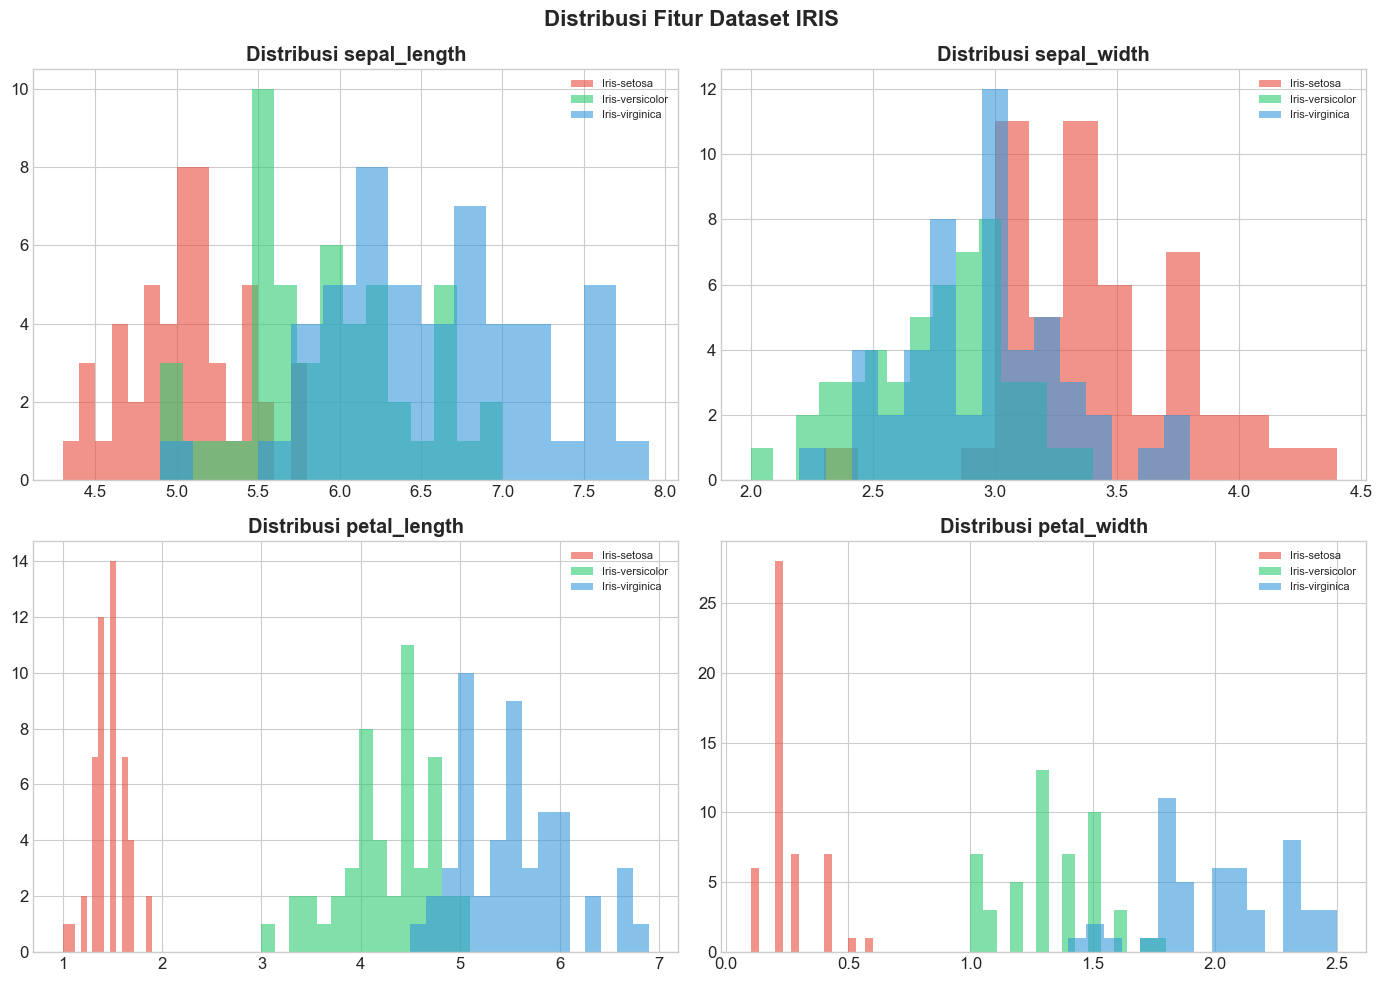

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = {'Iris-setosa': '#e74c3c', 'Iris-versicolor': '#2ecc71', 'Iris-virginica': '#3498db'}
for i, feat in enumerate(features):
    ax = axes[i//2][i%2]
    for sp in df['species'].unique():
        ax.hist(df[df['species']==sp][feat], alpha=0.6, label=sp, color=colors[sp], bins=15)
    ax.set_title(f'Distribusi {feat}', fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Distribusi Fitur Dataset IRIS', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


## 3. Workflow KNIME

Berikut adalah workflow KNIME yang digunakan untuk membandingkan **Random Forest**, **Decision Tree**, dan **Python Script** pada dataset IRIS.

### Workflow KNIME:
![Workflow KNIME](data/random_forest/node_knime.png)

Workflow terdiri dari 3 branch:
1. **Decision Tree Learner** -> Decision Tree Predictor -> Scorer
2. **Python Script** (Training) -> Python Script (Prediksi) -> Scorer
3. **Random Forest Learner** -> Random Forest Predictor -> Scorer


## 4. Script Python di KNIME

### 4.1 Script Training (Python Script Node 1)

Script berikut digunakan di node **Python Script** pertama untuk melatih model Random Forest dan menyimpannya menggunakan `joblib`:


```python
import knime.scripting.io as knio
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Ambil data training dari node KNIME Partitioning
data = knio.input_tables[0].to_pandas()

nama_kolom_target = 'species' 

# 2. Pisahkan fitur (X) dan target (y)
X_train = data.drop(nama_kolom_target, axis=1)
y_train = data[nama_kolom_target]

# 3. Inisialisasi dan latih Model Random Forest 
print("Training the model...")
model = RandomForestClassifier(n_estimators=100, random_state=43)
model.fit(X_train, y_train)
print("Model training complete.")

# 4. Menyimpan Model menggunakan Joblib
joblib_filename = 'D:\Application\knime-workspace/rf_model_iris.joblib'

print(f"Saving model to {joblib_filename} using joblib...")
joblib.dump(model, joblib_filename)
print("Model saved successfully with joblib.")

# Output status ke KNIME
knio.output_tables[0] = knio.Table.from_pandas(pd.DataFrame({"Status": [f"Model tersimpan di {joblib_filename}"]}))
```


### 4.2 Script Prediksi (Python Script Node 2)

Script berikut digunakan di node **Python Script** kedua untuk memuat model dan melakukan prediksi:

```python
import knime.scripting.io as knio
import pandas as pd
import joblib

# 1. Ambil data testing dari node KNIME Partitioning
data_test = knio.input_tables[0].to_pandas()

nama_kolom_target = 'species'

# Siapkan data untuk diprediksi (buang kolom target dari fitur)
if nama_kolom_target in data_test.columns:
    X_test = data_test.drop(nama_kolom_target, axis=1)
else:
    X_test = data_test

# 2. Memuat Model menggunakan Joblib
joblib_filename = 'D:\Application\knime-workspace/rf_model_iris.joblib'

print(f"Loading model from {joblib_filename} using joblib...")
loaded_model_joblib = joblib.load(joblib_filename)
print("Model loaded successfully with joblib.")

# 3. Lakukan Prediksi
prediction = loaded_model_joblib.predict(X_test)

# 4. Tambahkan hasil prediksi sebagai kolom baru bernama 'Prediction'
data_test['Prediction'] = prediction

# 5. Kirim hasil kembali ke KNIME untuk dinilai oleh node Scorer
knio.output_tables[0] = knio.Table.from_pandas(data_test)

```


## 5. Implementasi Random Forest dengan Python

Implementasi Python menggunakan parameter yang sama seperti script KNIME (`n_estimators=100, random_state=43`).


In [32]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

rf_model = RandomForestClassifier(n_estimators=100, random_state=43)
rf_model.fit(X, y)
rf_pred = rf_model.predict(X)

print('='*60)
print('RANDOM FOREST - HASIL PREDIKSI (150 data)')
print('='*60)
print(f'Jumlah Tree: {rf_model.n_estimators}')
print(f'Akurasi: {accuracy_score(y, rf_pred):.2%}')


RANDOM FOREST - HASIL PREDIKSI (150 data)
Jumlah Tree: 100
Akurasi: 100.00%


### Confusion Matrix - Random Forest (Python)

CONFUSION MATRIX - Random Forest (Python):
Predicted        Iris-setosa  Iris-versicolor  Iris-virginica
Actual                                                       
Iris-setosa               50                0               0
Iris-versicolor            0               50               0
Iris-virginica             0                0              50

Akurasi: 100.00%


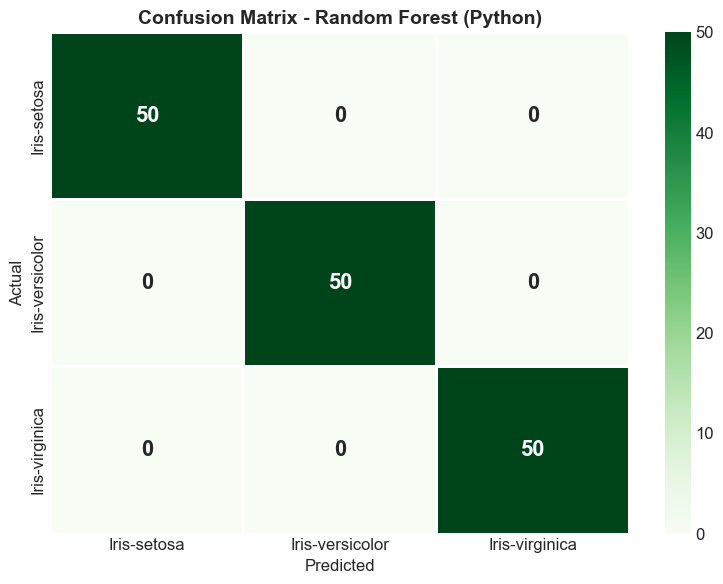

In [33]:
labels = sorted(y.unique())
cm_rf = confusion_matrix(y, rf_pred, labels=labels)
df_cm_rf = pd.DataFrame(cm_rf, index=labels, columns=labels)
df_cm_rf.index.name = 'Actual'; df_cm_rf.columns.name = 'Predicted'

print('CONFUSION MATRIX - Random Forest (Python):')
print(df_cm_rf)
print(f'\nAkurasi: {accuracy_score(y, rf_pred):.2%}')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_cm_rf, annot=True, fmt='d', cmap='Greens', linewidths=2,
            linecolor='white', annot_kws={'size':16,'weight':'bold'})
ax.set_title('Confusion Matrix - Random Forest (Python)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [34]:
print('CLASSIFICATION REPORT - Random Forest (Python):')
print(classification_report(y, rf_pred))


CLASSIFICATION REPORT - Random Forest (Python):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       1.00      1.00      1.00        50
 Iris-virginica       1.00      1.00      1.00        50

       accuracy                           1.00       150
      macro avg       1.00      1.00      1.00       150
   weighted avg       1.00      1.00      1.00       150



### Feature Importance - Random Forest

Feature Importance:
       Fitur  Importance
 petal_width    0.471449
petal_length    0.376176
sepal_length    0.125803
 sepal_width    0.026572


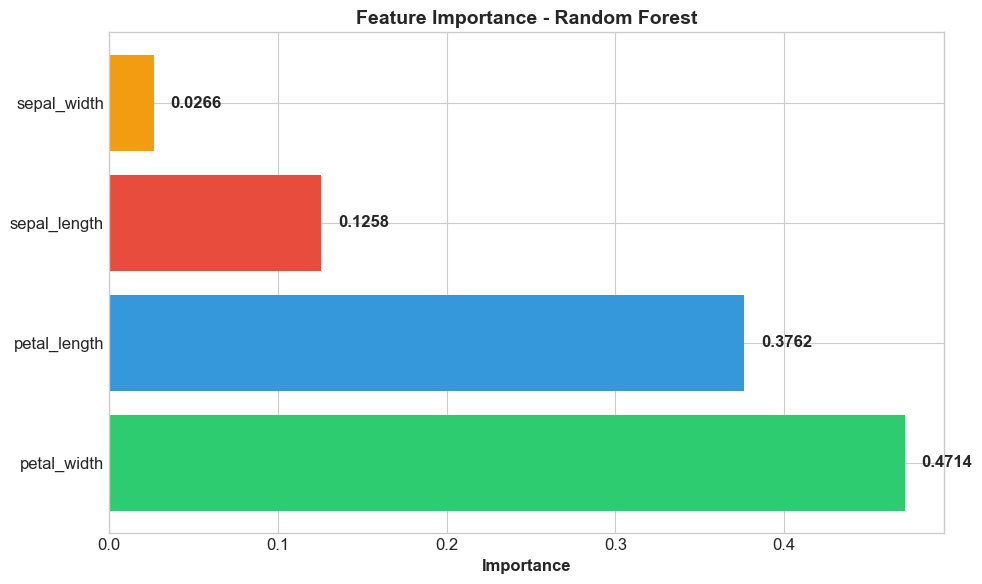

In [35]:
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Fitur': features, 'Importance': importances}).sort_values('Importance', ascending=False)
print('Feature Importance:'); print(feat_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp['Fitur'], feat_imp['Importance'], color=['#2ecc71','#3498db','#e74c3c','#f39c12'])
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout(); plt.show()


## 6. Hasil KNIME - Random Forest Learner

### Confusion Matrix (KNIME - Random Forest):
![CM RF KNIME](data/random_forest/node_score_matrix.png)

### Accuracy Statistics (KNIME - Random Forest):
![Acc RF KNIME](data/random_forest/node_score_acurracy.png)

**Hasil KNIME Random Forest:**
- Iris-setosa: TP=50, FP=0 -> **Accuracy = 100%**
- Iris-versicolor: TP=50, FP=0 -> **Accuracy = 100%**
- Iris-virginica: TP=50, FP=0 -> **Accuracy = 100%**
- **Overall Accuracy = 100%**


### Hasil Python Script di KNIME:

#### Confusion Matrix (Python Script di KNIME):
![CM Py KNIME](data/random_forest/python_script_score_matrix.png)

#### Accuracy (Python Script di KNIME):
![Acc Py KNIME](data/random_forest/python_script_score_acurracy.png)

Hasil Python Script di KNIME juga menunjukkan **akurasi 100%**, konsisten dengan Random Forest Learner node.


## 7. Hasil KNIME - Decision Tree Learner

### Workflow Decision Tree:
![WF DT](data/Decision_Tree_Leaner/hasil_knime/workflow.png)

### Confusion Matrix (KNIME - Decision Tree):
![CM DT](data/Decision_Tree_Leaner/hasil_knime/matrix.png)

### Accuracy Statistics (KNIME - Decision Tree):
![Acc DT](data/Decision_Tree_Leaner/hasil_knime/accuracy.png)

**Hasil KNIME Decision Tree:**
- Iris-setosa: TP=50, FP=0 -> **Precision=1.0, Recall=1.0**
- Iris-versicolor: TP=49, FP=5 -> **Precision=0.907, Recall=0.98**
- Iris-virginica: TP=45, FP=1 -> **Precision=0.978, Recall=0.9**
- **Overall Accuracy = 96%**


## 8. Perbandingan KNIME: Random Forest vs Decision Tree

Berikut perbandingan hasil **KNIME Random Forest Learner** vs **KNIME Decision Tree Learner** pada dataset IRIS (150 data).


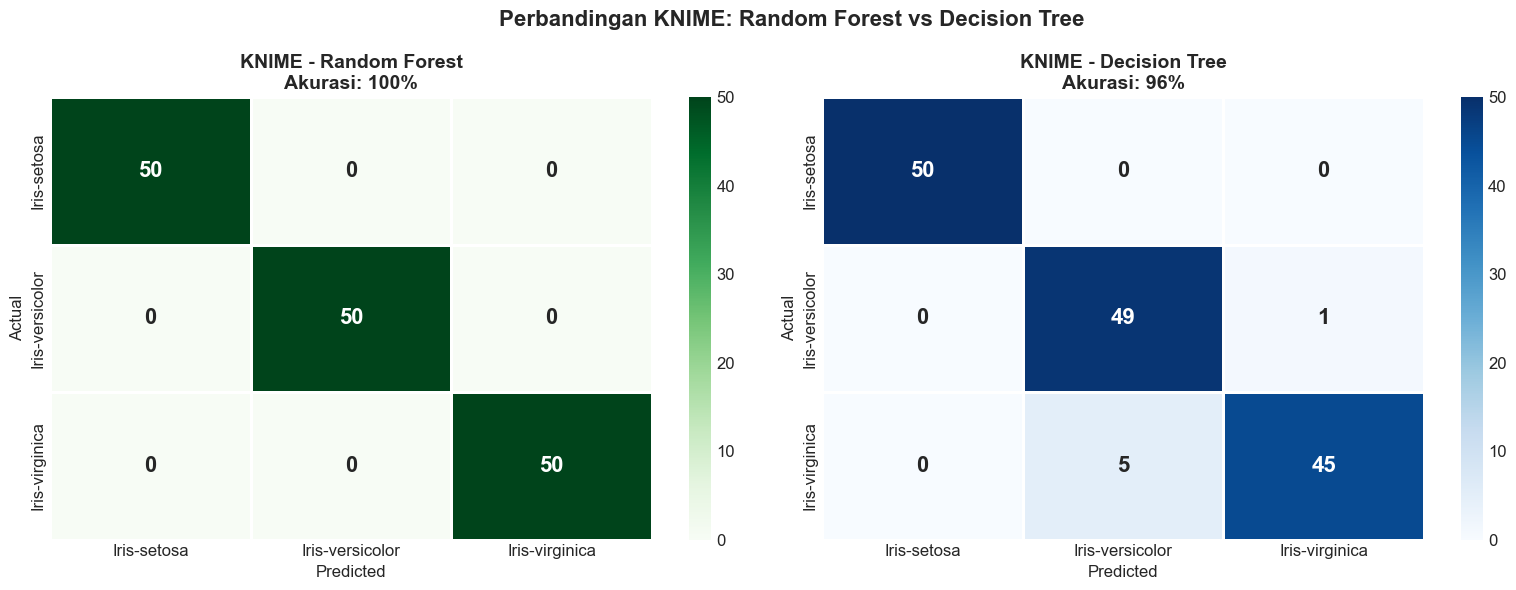

In [36]:
# Reproduksi Confusion Matrix dari KNIME untuk perbandingan visual

# KNIME Random Forest: Akurasi 100%
cm_knime_rf = np.array([[50, 0, 0], [0, 50, 0], [0, 0, 50]])
labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
df_cm_knime_rf = pd.DataFrame(cm_knime_rf, index=labels, columns=labels)
df_cm_knime_rf.index.name = 'Actual'; df_cm_knime_rf.columns.name = 'Predicted'

# KNIME Decision Tree: Akurasi 96%
cm_knime_dt = np.array([[50, 0, 0], [0, 49, 1], [0, 5, 45]])
df_cm_knime_dt = pd.DataFrame(cm_knime_dt, index=labels, columns=labels)
df_cm_knime_dt.index.name = 'Actual'; df_cm_knime_dt.columns.name = 'Predicted'

# Visualisasi side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_cm_knime_rf, annot=True, fmt='d', cmap='Greens', linewidths=2,
            linecolor='white', annot_kws={'size':16,'weight':'bold'}, ax=axes[0])
axes[0].set_title('KNIME - Random Forest\nAkurasi: 100%', fontsize=14, fontweight='bold')

sns.heatmap(df_cm_knime_dt, annot=True, fmt='d', cmap='Blues', linewidths=2,
            linecolor='white', annot_kws={'size':16,'weight':'bold'}, ax=axes[1])
axes[1].set_title('KNIME - Decision Tree\nAkurasi: 96%', fontsize=14, fontweight='bold')

plt.suptitle('Perbandingan KNIME: Random Forest vs Decision Tree',
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


In [37]:
# Tabel perbandingan detail KNIME RF vs KNIME DT
comparison = pd.DataFrame({
    'Metrik': ['TP Setosa', 'FP Setosa', 'TP Versicolor', 'FP Versicolor',
               'TP Virginica', 'FP Virginica', 'Total Benar', 'Total Salah', 'Overall Accuracy'],
    'KNIME Random Forest': [50, 0, 50, 0, 50, 0, 150, 0, '100%'],
    'KNIME Decision Tree': [50, 0, 49, 5, 45, 1, 144, 6, '96%']
})

print('='*70)
print('PERBANDINGAN KNIME: Random Forest vs Decision Tree')
print('='*70)
comparison


PERBANDINGAN KNIME: Random Forest vs Decision Tree


,Metrik,KNIME Random Forest,KNIME Decision Tree
0,TP Setosa,50,50
1,FP Setosa,0,0
2,TP Versicolor,50,49
3,FP Versicolor,0,5
4,TP Virginica,50,45
5,FP Virginica,0,1
6,Total Benar,150,144
7,Total Salah,0,6
8,Overall Accuracy,100%,96%


### Analisis Perbedaan

Pada **KNIME Decision Tree**, terdapat **6 data yang salah prediksi**:
- 1 data Iris-versicolor salah diprediksi sebagai Iris-virginica
- 5 data Iris-virginica salah diprediksi sebagai Iris-versicolor

Kesalahan ini terjadi karena **Iris-versicolor dan Iris-virginica** memiliki karakteristik yang mirip, terutama pada fitur `petal_length` dan `petal_width`.

Sebaliknya, **KNIME Random Forest** berhasil mengklasifikasikan **semua 150 data dengan benar** (akurasi 100%). 
Hal ini menunjukkan keunggulan metode ensemble yang menggabungkan banyak tree untuk mengurangi kesalahan prediksi.


### Visualisasi Perbandingan Akurasi KNIME

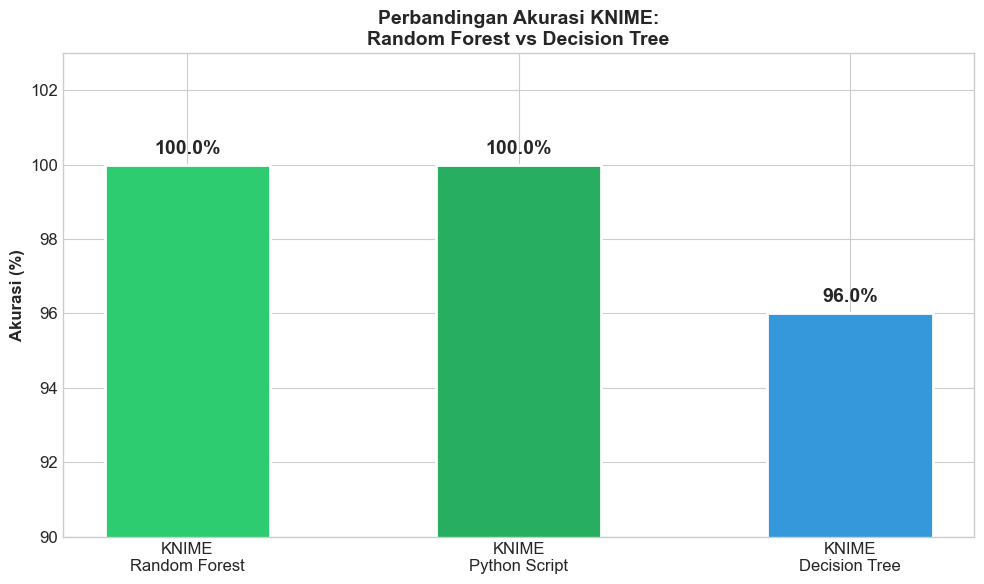

In [38]:
methods = ['KNIME\nRandom Forest', 'KNIME\nPython Script', 'KNIME\nDecision Tree']
accs = [100.0, 100.0, 96.0]
colors_bar = ['#2ecc71', '#27ae60', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(methods, accs, color=colors_bar, edgecolor='white', linewidth=2, width=0.5)
ax.set_ylabel('Akurasi (%)', fontweight='bold')
ax.set_title('Perbandingan Akurasi KNIME:\nRandom Forest vs Decision Tree',
             fontsize=14, fontweight='bold')
ax.set_ylim(90, 103)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()


## 9. Kesimpulan

### Perbandingan KNIME: Random Forest vs Decision Tree pada Dataset IRIS

| Aspek | Random Forest (KNIME) | Decision Tree (KNIME) |
|-------|----------------------|----------------------|
| **Overall Accuracy** | **100%** | **96%** |
| **Data Salah Prediksi** | 0 | 6 |
| **Akurasi Setosa** | 100% | 100% |
| **Akurasi Versicolor** | 100% | 98% (Recall) |
| **Akurasi Virginica** | 100% | 90% (Recall) |
| **Overfitting** | Lebih tahan | Rentan |
| **Interpretability** | Rendah (black box) | Tinggi (white box) |
| **Jumlah Model** | Ensemble (banyak tree) | Single tree |

### Temuan Utama:

1. **Random Forest (KNIME) mencapai akurasi 100%** - semua 150 data diklasifikasikan dengan benar
2. **Decision Tree (KNIME) mencapai akurasi 96%** - 6 data salah prediksi (antara Versicolor dan Virginica)
3. **Python Script di KNIME** juga mencapai akurasi 100%, konsisten dengan Random Forest Learner node
4. **Random Forest lebih unggul** dalam akurasi karena menggunakan ensemble method
5. **Kelemahan Random Forest**: model lebih sulit diinterpretasikan dibanding single Decision Tree

> **Rekomendasi:** Untuk dataset IRIS, **Random Forest** adalah pilihan lebih baik dari segi akurasi. 
Namun, jika interpretabilitas menjadi prioritas, **Decision Tree** tetap valid dengan akurasi 96%.
